In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import AFT_tools as AFT

plt.style.use('../libs/my_style.mplstyle')

# ファイルパスの設定
path = "/Users/sasakinozomu/Desktop/260312_0002_band_data.csv"
data = pd.read_csv(path)

output_folder = "/Users/sasakinozomu/Desktop"

In [5]:
Vol = data["Norm. Raw Volume"]
BSA = Vol[0:4].to_list()
Kinesin = Vol[4:9].to_list()

/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_82394/2659680435.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Kinesin concentration 1: 8.96 μM
Kinesin concentration 2: 4.27 μM
Kinesin concentration 3: 5.63 μM
Kinesin concentration 4: 2.95 μM


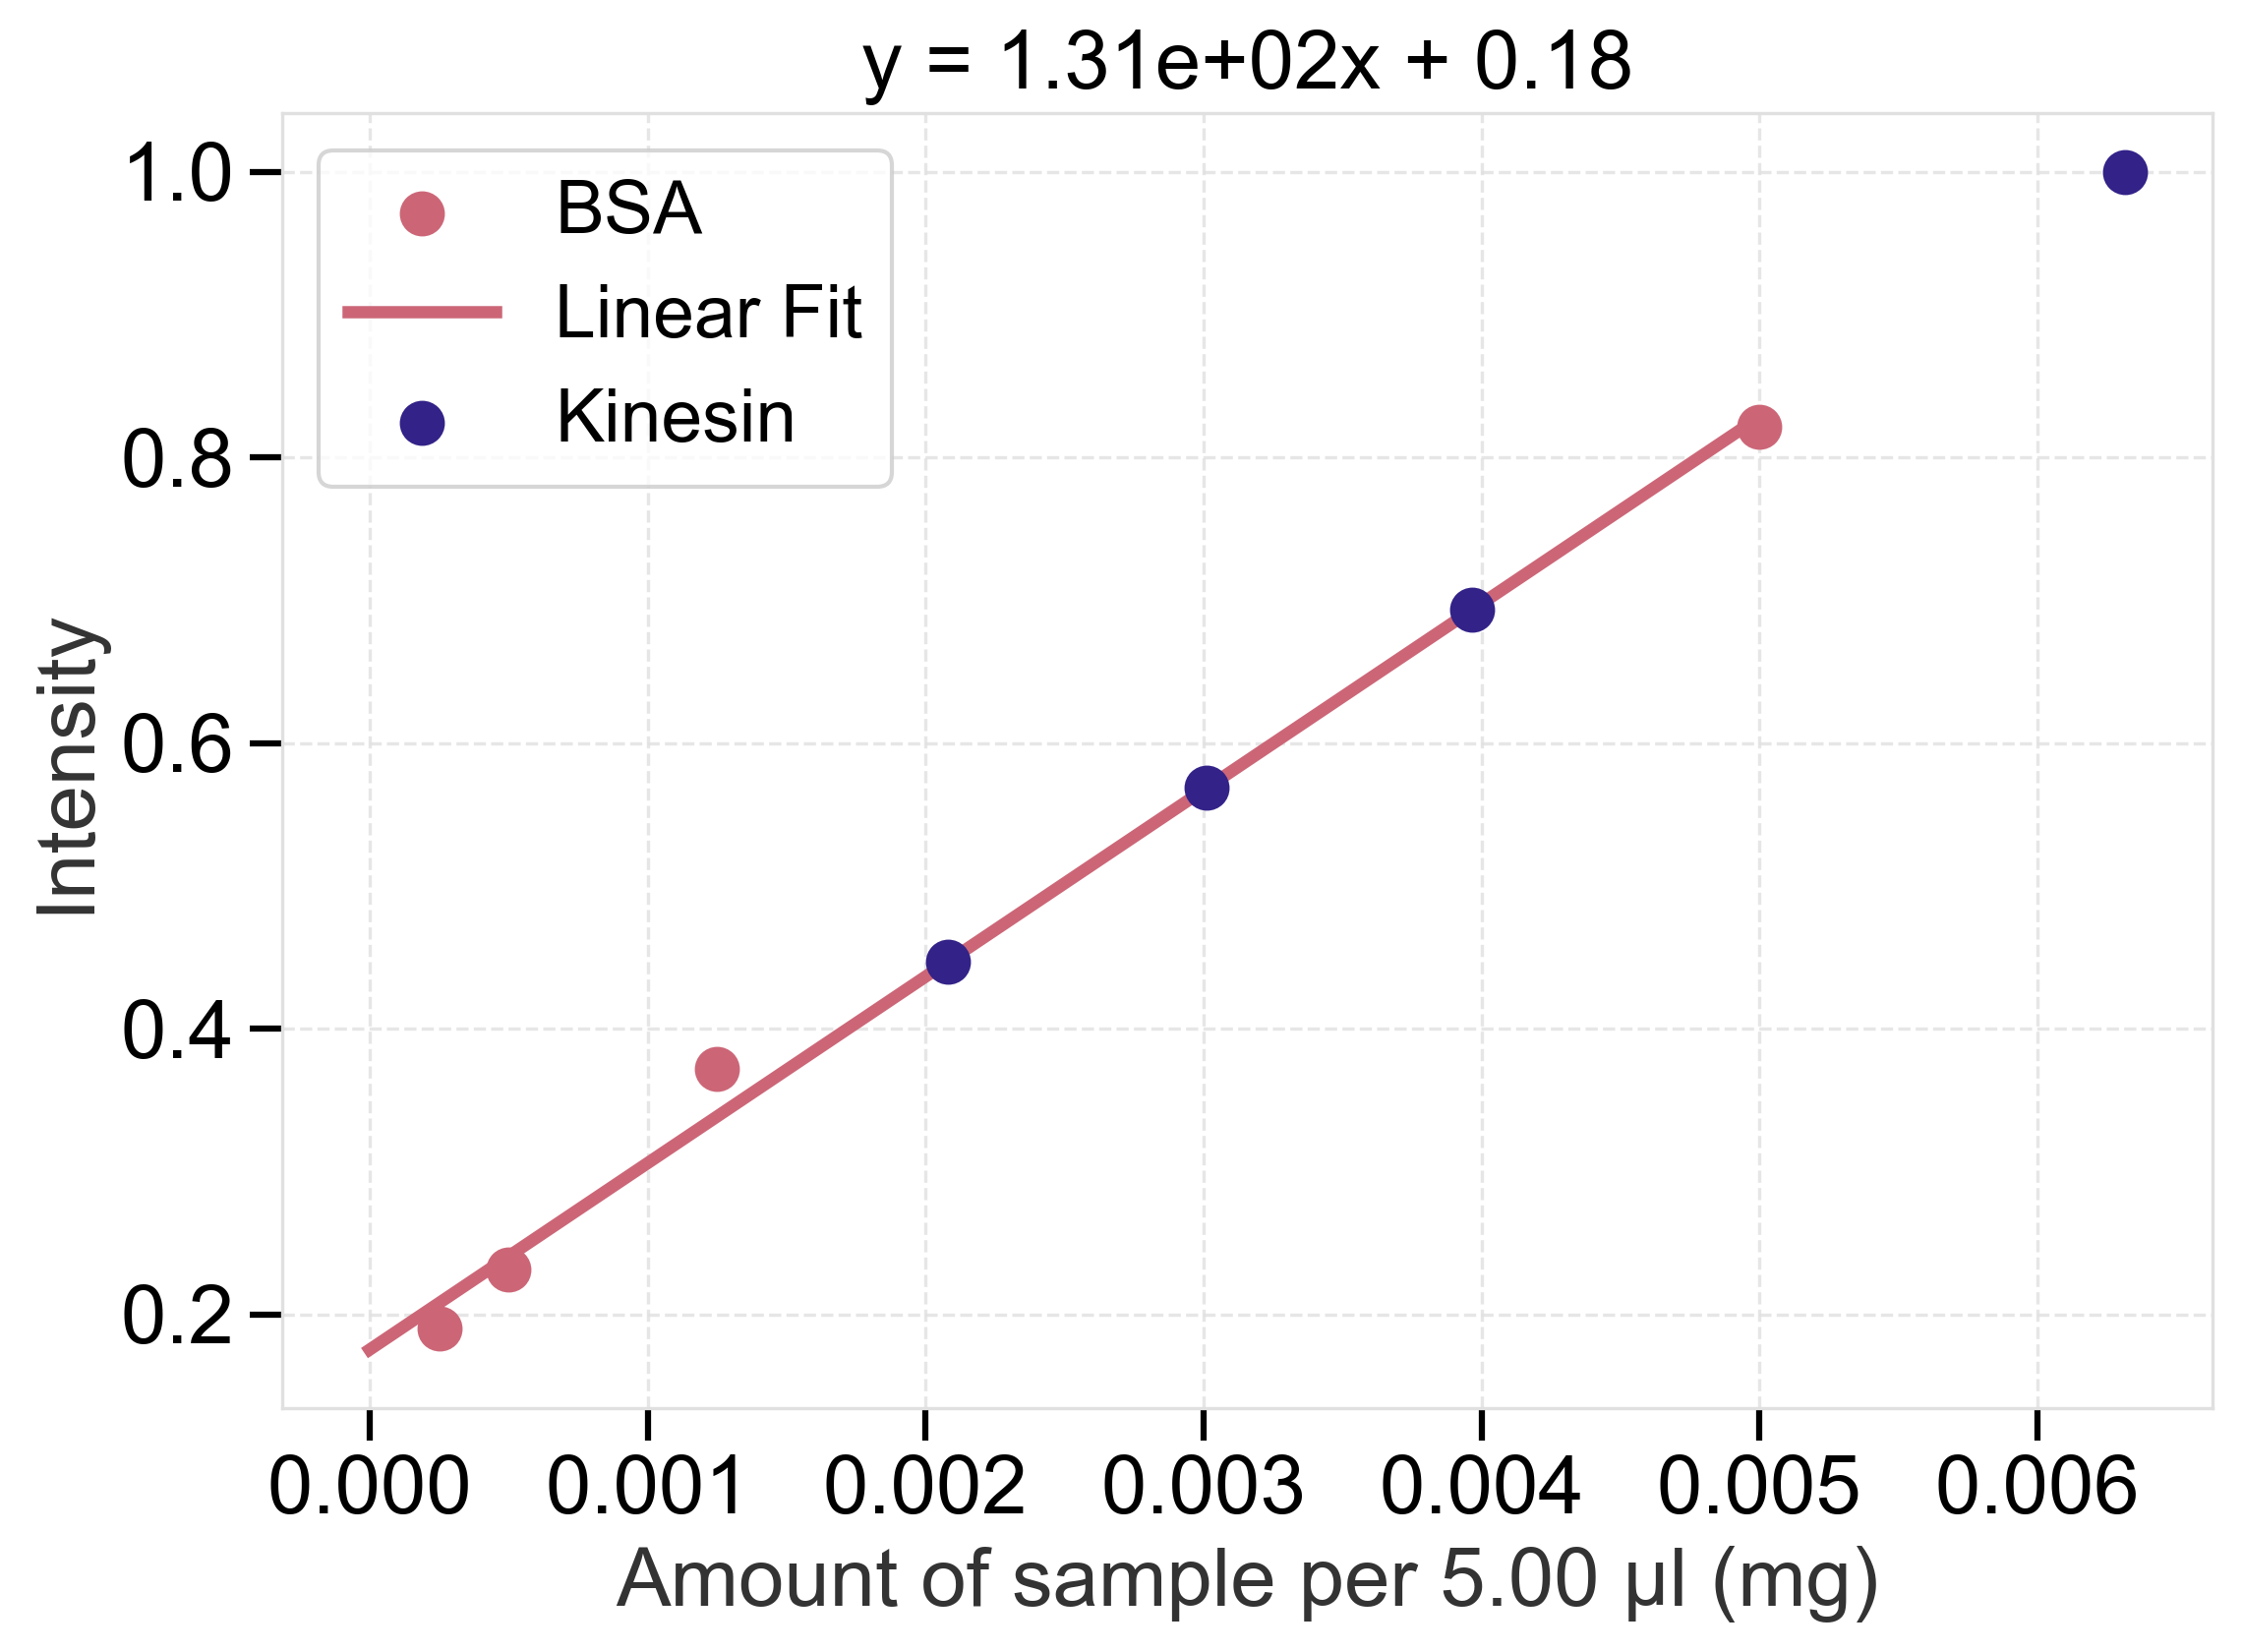

In [6]:
# データの読み込み

# 定数
WHITE_KINESIN_KDA = 70.5 * 10**3  # kDa
WHITE_KINESIN_M = 2 * WHITE_KINESIN_KDA * 1.6605402 * 1e-24 * 6.02 * 1e23  # g/mol to μM

colors = [(255/255, 75/255, 0/255), (246/255, 170/255, 0/255), (255/255, 241/255, 0/255), (153 / 255, 0 / 255, 153 / 255), (3 / 255, 175 / 255, 122 / 255),  (77/255, 196/255, 255/255)] #red, orange, yellow, green, purple, sky

# BSAデータ
BSA_x = np.array([1.0, 0.25, 0.1, 0.05]) * 5e-3  # mg/5.00 μl

# Kinesinデータ

# 線形フィッティング
def linear_fit(x, a, b):
    return a * x + b

# 最初の3点でフィット
params, covariance = curve_fit(linear_fit, BSA_x, BSA)
a, b = params

# フィット直線の描画
x_fit = np.linspace(0, 0.005, 100)
y_fit = linear_fit(x_fit, a, b)

fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(BSA_x, BSA, label='BSA', s=100)
ax.plot(x_fit, y_fit, label='Linear Fit')
ax.set(xlabel='Amount of sample per 5.00 μl (mg)',
       ylabel='Intensity',
       title=f'y = {a:.2e}x + {b:.2f}')

# Kinesin濃度計算
def calc_concentration(y, a, b):
    return (y - b) / a

kinesin_x = calc_concentration(Kinesin, a, b)
kinesin_mg_per_ml = kinesin_x * 200
kinesin_conc = (1e6) * kinesin_mg_per_ml / WHITE_KINESIN_M  # μM

ax.scatter(kinesin_x, Kinesin, label='Kinesin', s=100, zorder=2)

ax.legend()
fig.show()
fig.savefig(f"{output_folder}BSA_fit.png", bbox_inches = 'tight')
fig.savefig(f"{output_folder}BSA_fit.pdf", bbox_inches = 'tight')


for i, conc in enumerate(kinesin_conc):
    print(f"Kinesin concentration {i+1}: {conc:.2f} μM")

f = open(f'{output_folder}_fit.txt', 'w')
f.write(f'{kinesin_conc} μM')
f.close()